# Phase 4: Latent Manifold t-SNE & Closed-Loop Bias Visualization

This notebook implements **2D t-SNE manifold projections** to visualize how closed-loop feedback loops distort the latent representation of items across simulation generations ($t=0$ vs $t=T-1$).

### Key Visual Analyses:
1. **Benchmark Metric Trajectories**: 4-tier dashboard across generations (Gini, KL Drift, NDCG, Effective Rank).
2. **Joint t-SNE Popularity Drift**: Visualizing how popular items act as geometric attractors and marginalize the long tail.
3. **Genre Homogenization**: Investigating whether genre clusters collapse or polarize.
4. **Manifold Density Compression**: 2D KDE contour density mapping showing latent space compression.


In [1]:
import os
import sys
import json
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd

sys.path.insert(0, '..')

from src.data.dataset import load_movielens_1m
from src.data.buffer import merge_and_deduplicate
from src.adapters.cornac_adapters import CornacBPRAdapter, CornacMFAdapter
from src.engine import simulate_user_clicks

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 150
})


/Users/shravanpandala/Projects/recommender-bias-propagation/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Multi-Tier Benchmark Metric Trajectories
Visualizing the results across 10 generations from `docs/benchmarks/run_20260915_115435_d66c44.json`.

Loading latest benchmark run: ../docs/benchmarks/run_20260915_115435_d66c44.json


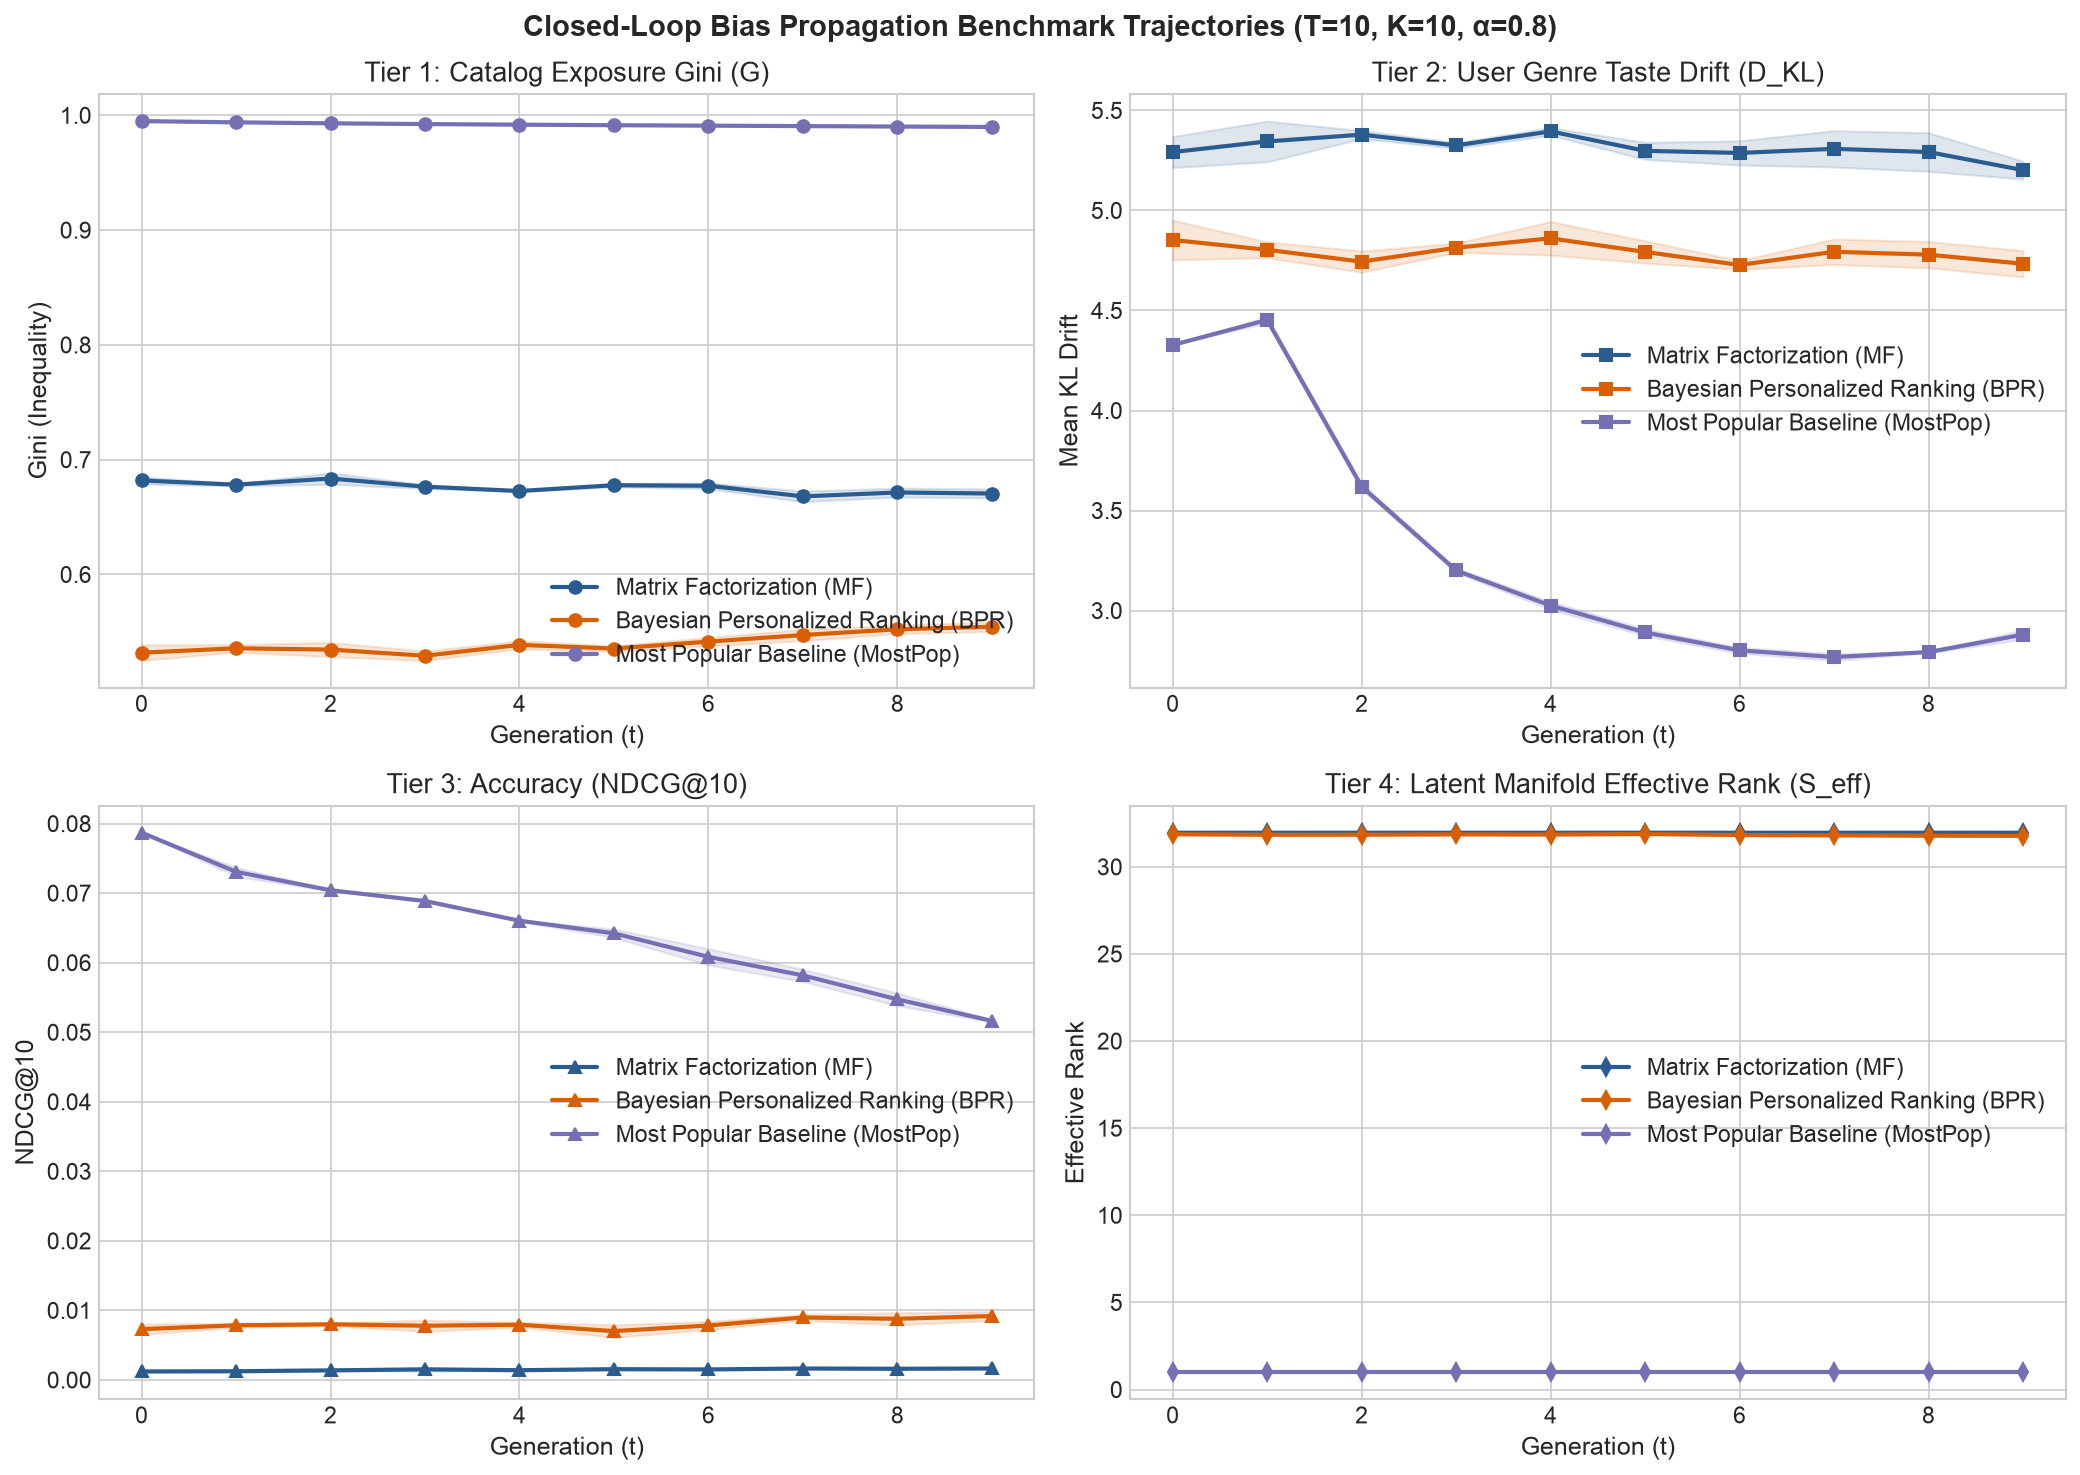

In [2]:
import glob

json_files = glob.glob('../docs/benchmarks/*.json')
benchmark_file = max(json_files, key=os.path.getmtime)
print(f"Loading latest benchmark run: {benchmark_file}")

with open(benchmark_file, 'r', encoding='utf-8') as f:
    benchmark_data = json.load(f)

results = benchmark_data['results']
T = benchmark_data.get('generations', 10)
generations = np.arange(T)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Closed-Loop Bias Propagation Benchmark Trajectories (T={T}, K={benchmark_data.get('k', 10)}, α={benchmark_data.get('alpha', 0.8)})", fontsize=14, fontweight='bold')

palette = {'Matrix Factorization (MF)': '#2b5c8f', 
           'Bayesian Personalized Ranking (BPR)': '#d95f02', 
           'Most Popular Baseline (MostPop)': '#7570b3'}

# Gini
ax1 = axes[0, 0]
for model_name, metrics in results.items():
    mean = np.array(metrics['gini']['mean'])
    std = np.array(metrics['gini']['std']) if 'std' in metrics['gini'] else np.zeros_like(mean)
    c = palette.get(model_name, None)
    ax1.plot(generations, mean, label=model_name, color=c, marker='o', lw=2)
    ax1.fill_between(generations, mean - std, mean + std, color=c, alpha=0.15)
ax1.set_title('Tier 1: Catalog Exposure Gini (G)')
ax1.set_xlabel('Generation (t)')
ax1.set_ylabel('Gini (Inequality)')
ax1.legend(loc='lower right')

# KL Drift
ax2 = axes[0, 1]
for model_name, metrics in results.items():
    mean = np.array(metrics['kl_drift']['mean'])
    std = np.array(metrics['kl_drift']['std']) if 'std' in metrics['kl_drift'] else np.zeros_like(mean)
    c = palette.get(model_name, None)
    ax2.plot(generations, mean, label=model_name, color=c, marker='s', lw=2)
    ax2.fill_between(generations, mean - std, mean + std, color=c, alpha=0.15)
ax2.set_title('Tier 2: User Genre Taste Drift (D_KL)')
ax2.set_xlabel('Generation (t)')
ax2.set_ylabel('Mean KL Drift')
ax2.legend()

# NDCG@10
ax3 = axes[1, 0]
for model_name, metrics in results.items():
    mean = np.array(metrics['ndcg']['mean'])
    std = np.array(metrics['ndcg']['std']) if 'std' in metrics['ndcg'] else np.zeros_like(mean)
    c = palette.get(model_name, None)
    ax3.plot(generations, mean, label=model_name, color=c, marker='^', lw=2)
    ax3.fill_between(generations, mean - std, mean + std, color=c, alpha=0.15)
ax3.set_title('Tier 3: Accuracy (NDCG@10)')
ax3.set_xlabel('Generation (t)')
ax3.set_ylabel('NDCG@10')
ax3.legend()

# Effective Rank
ax4 = axes[1, 1]
for model_name, metrics in results.items():
    mean = np.array(metrics['s_eff']['mean'])
    std = np.array(metrics['s_eff']['std']) if 'std' in metrics['s_eff'] else np.zeros_like(mean)
    c = palette.get(model_name, None)
    ax4.plot(generations, mean, label=model_name, color=c, marker='d', lw=2)
    ax4.fill_between(generations, mean - std, mean + std, color=c, alpha=0.15)
ax4.set_title('Tier 4: Latent Manifold Effective Rank (S_eff)')
ax4.set_xlabel('Generation (t)')
ax4.set_ylabel('Effective Rank')
ax4.legend(loc='center right')

plt.tight_layout()
plt.show()


## 2. Ingest Dataset & Simulate Closed-Loop Bias for BPR
Extracting item embeddings at initial generation ($t=0$) and after 10 feedback generations ($t=9$).

In [3]:
train_mat, test_mat, u2c, i2c = load_movielens_1m('../ml-1m/ratings.dat', threshold=4.0, split_ratio=0.8)
n_users, n_items = train_mat.shape

# Extract primary movie genres
df_movies = pd.read_csv('../ml-1m/movies.dat', sep='::', names=['item_id', 'title', 'genres'], engine='python', encoding='latin-1')
primary_genres = ['Unknown'] * n_items
for _, row in df_movies.iterrows():
    raw_id = row['item_id']
    if raw_id in i2c:
        code = i2c[raw_id]
        genres = str(row['genres']).split('|')
        primary_genres[code] = genres[0] if genres else 'Unknown'

# Run simulation for BPR
T = 10
D_t = train_mat.copy()
active_users = np.arange(n_users, dtype=np.int32)

model = CornacBPRAdapter(dim=16, max_iter=30)
model.fit(D_t, seed=42)
U_0, V_0 = model.get_embeddings()
U_star, V_star = U_0.copy(), V_0.copy()

for t in range(T):
    recs = model.recommend(active_users, k=10, remove_seen=True)
    pop_counts = np.array(D_t.sum(axis=0)).flatten()
    u_clicks, i_clicks = simulate_user_clicks(
        recs=recs, U_star=U_star, V_star=V_star, pop_counts=pop_counts,
        alpha=0.8, tau=1.0, seed=42 + t
    )
    D_t = merge_and_deduplicate(D_t, (u_clicks, i_clicks))
    if t < T - 1:
        model = CornacBPRAdapter(dim=16, max_iter=30)
        model.fit(D_t, seed=42 + t + 1)

_, V_final = model.get_embeddings()
print('Embeddings extracted successfully: V_0 shape:', V_0.shape, 'V_final shape:', V_final.shape)


Embeddings extracted successfully: V_0 shape: (3533, 16) V_final shape: (3533, 16)


## 3. Joint 2D t-SNE Projection
Concatenating $[V_0; V_9]$ and fitting a joint t-SNE ensures both generations share an identical coordinate space without rotational skew.

In [4]:
V_joint = np.vstack([V_0, V_final])
tsne = TSNE(n_components=2, perplexity=30.0, random_state=42, init='pca', learning_rate='auto', max_iter=1000)
coords_joint = tsne.fit_transform(V_joint)

coords_0 = coords_joint[:n_items]
coords_final = coords_joint[n_items:]

base_pop = np.array(train_mat.sum(axis=0)).flatten()
final_pop = np.array(D_t.sum(axis=0)).flatten()
log_base_pop = np.log10(np.maximum(base_pop, 1))
log_final_pop = np.log10(np.maximum(final_pop, 1))


## 4. Visual 1: Popularity Gradient & Drift Arrows
The red arrows trace the trajectory of the top-50 most popular movies, illustrating how high-exposure items migrate into dense attractors while long-tail items are marginalized.

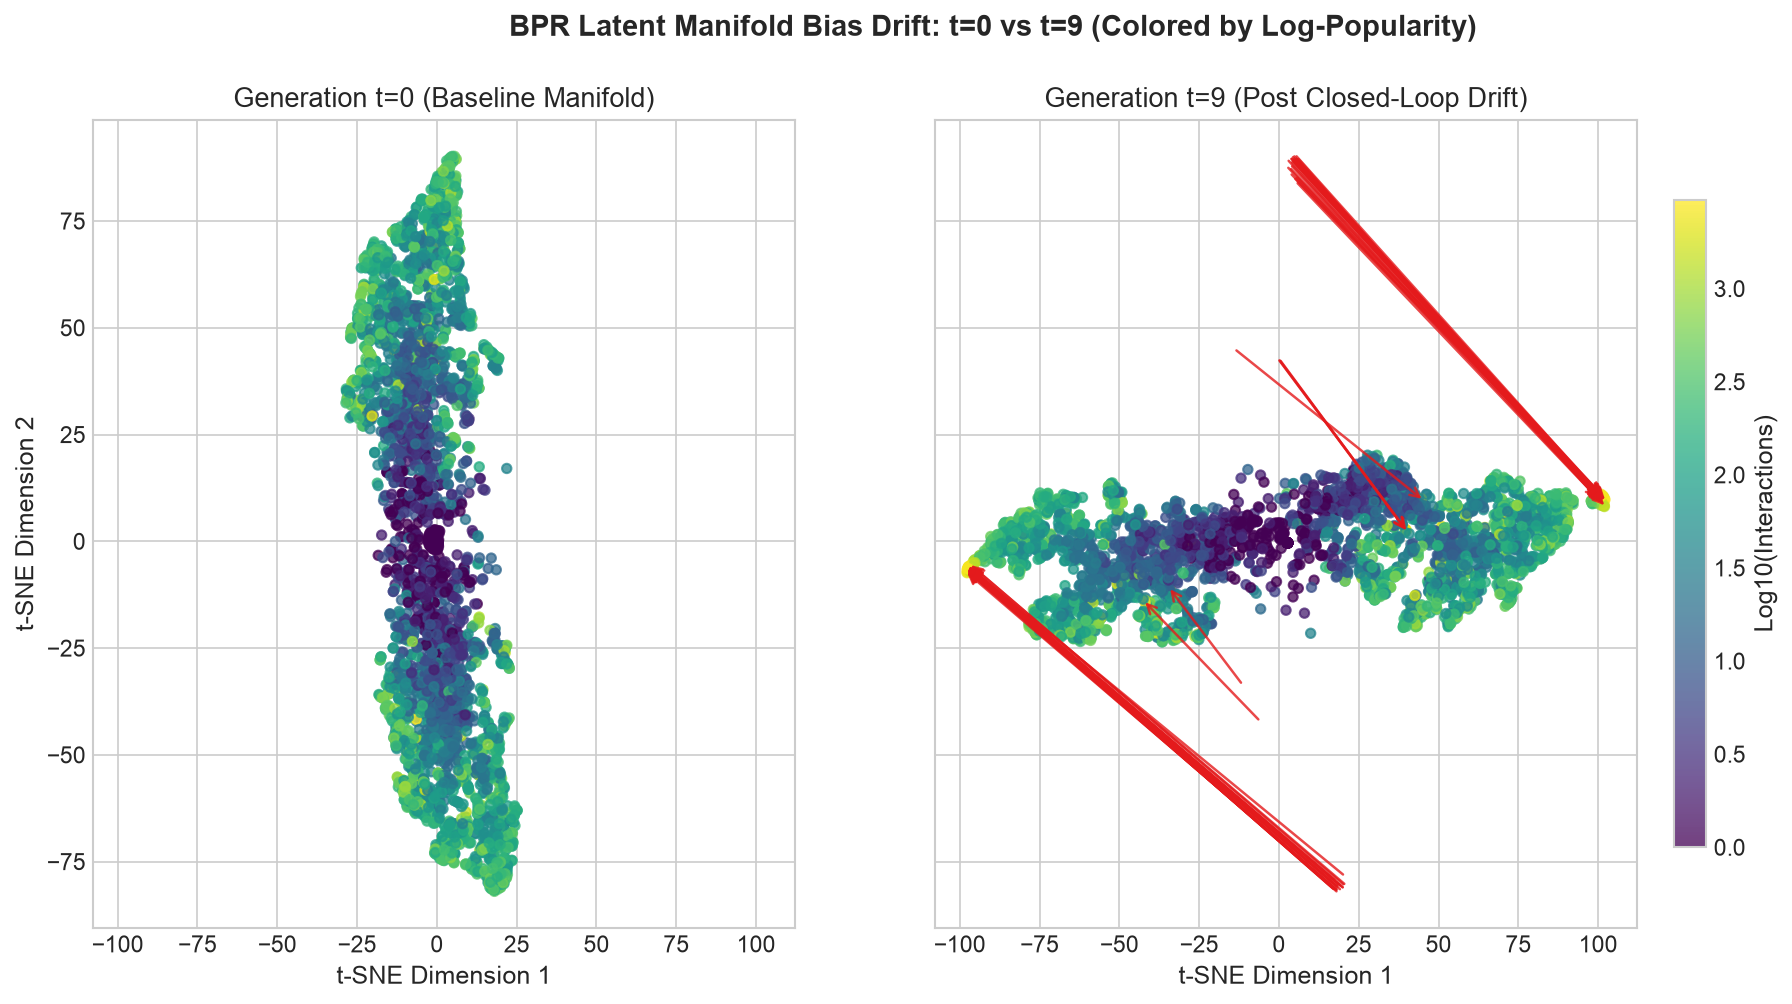

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
fig.suptitle('BPR Latent Manifold Bias Drift: t=0 vs t=9 (Colored by Log-Popularity)', fontsize=14, fontweight='bold')

sc0 = axes[0].scatter(coords_0[:, 0], coords_0[:, 1], c=log_base_pop, cmap='viridis', s=20, alpha=0.75)
axes[0].set_title('Generation t=0 (Baseline Manifold)')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')

sc1 = axes[1].scatter(coords_final[:, 0], coords_final[:, 1], c=log_final_pop, cmap='viridis', s=20, alpha=0.75)
top_pop_indices = np.argsort(final_pop)[-50:]
for idx in top_pop_indices:
    axes[1].annotate('', xy=(coords_final[idx, 0], coords_final[idx, 1]), xytext=(coords_0[idx, 0], coords_0[idx, 1]),
                     arrowprops=dict(arrowstyle='->', color='#e41a1c', lw=1.2, alpha=0.8, shrinkA=0, shrinkB=0))
axes[1].set_title('Generation t=9 (Post Closed-Loop Drift)')
axes[1].set_xlabel('t-SNE Dimension 1')

cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), shrink=0.8, pad=0.02)
cbar.set_label('Log10(Interactions)')
plt.show()


## 5. Visual 2: Primary Movie Genre Clusters
Examining whether genre boundaries remain intact or blur under closed-loop recommendation bias.

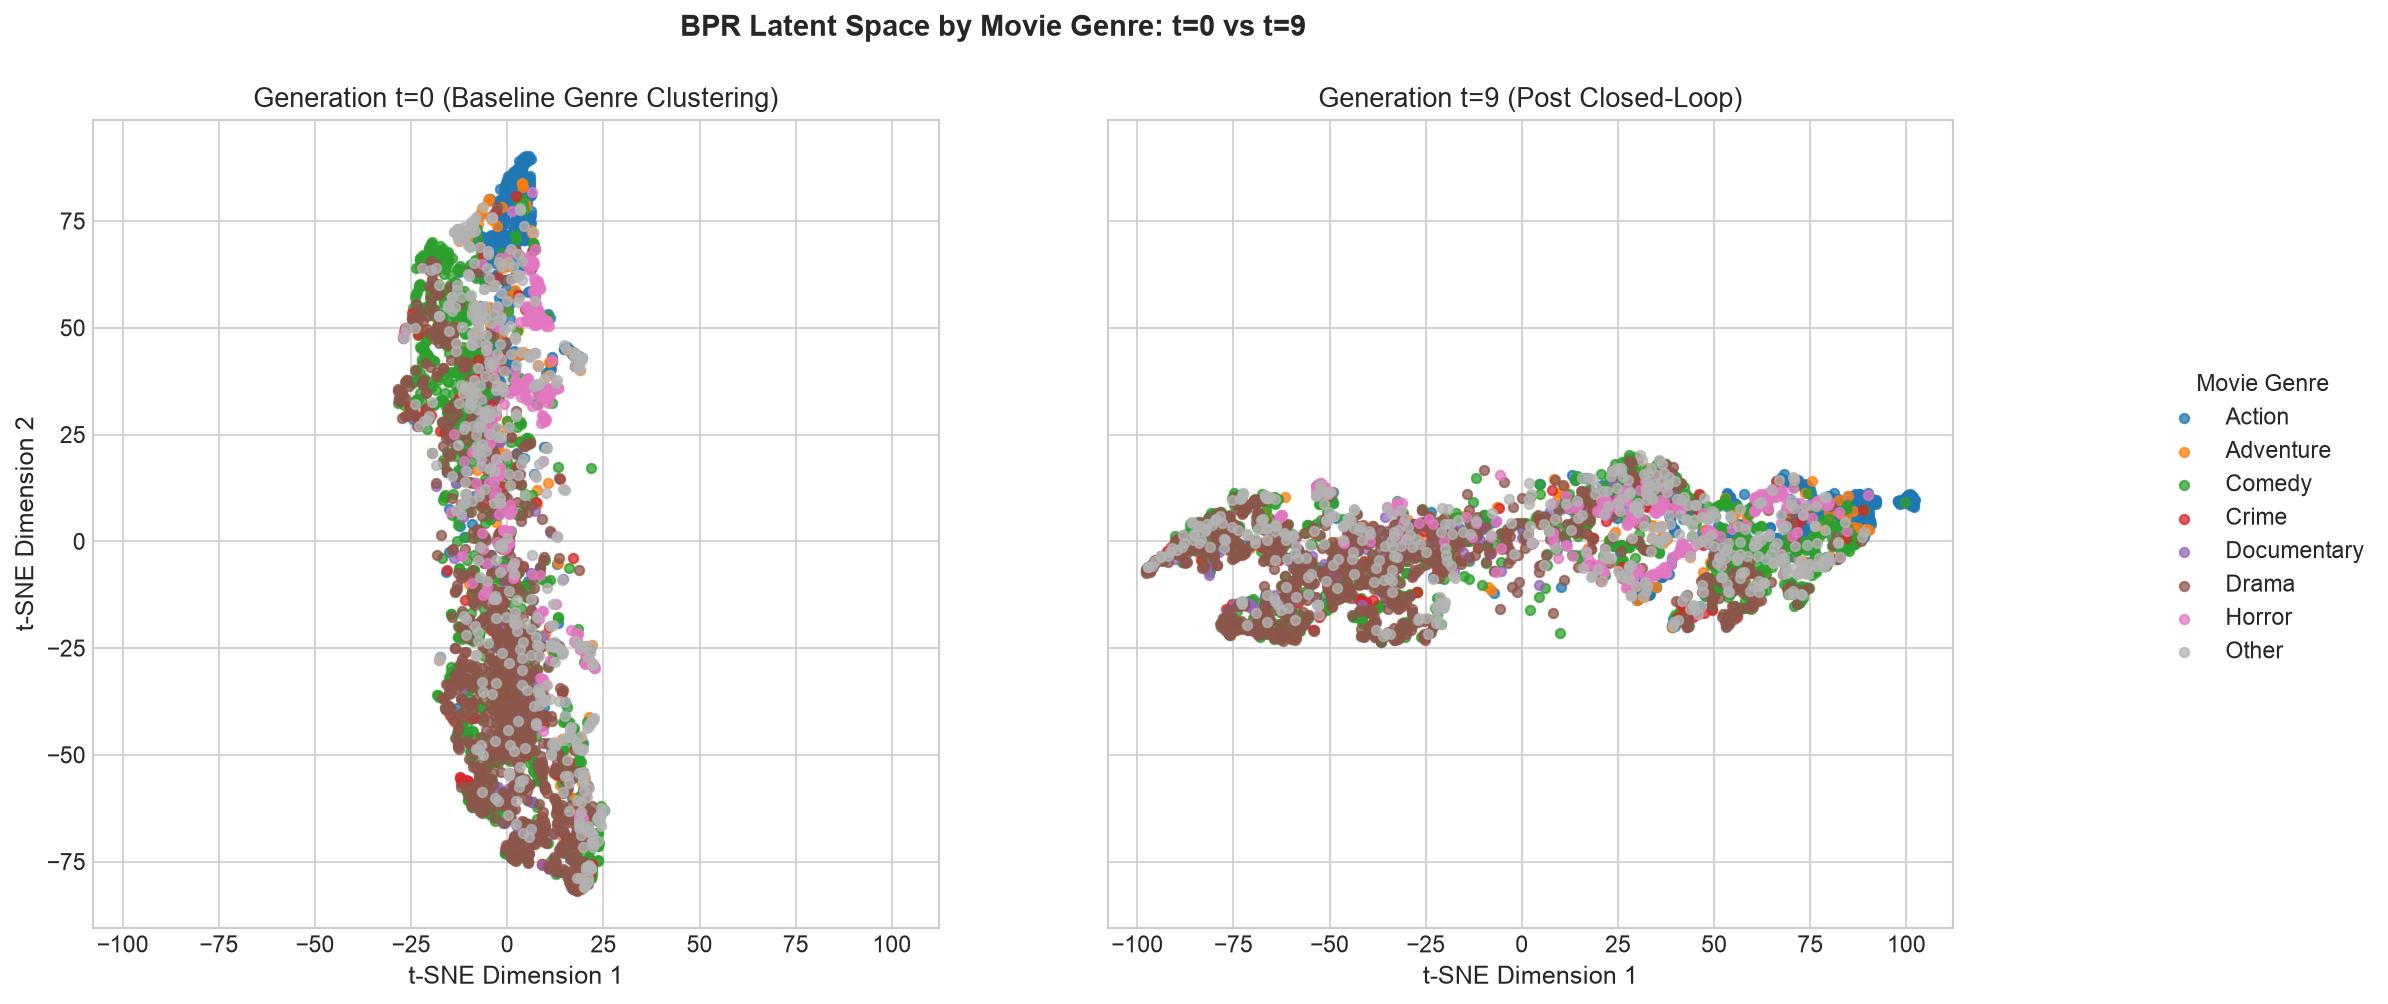

In [6]:
genre_series = pd.Series(primary_genres)
top_genres = genre_series.value_counts().nlargest(7).index.tolist()
mapped_genres = [g if g in top_genres else 'Other' for g in primary_genres]
unique_labels = sorted(list(set(mapped_genres)))
if 'Other' in unique_labels:
    unique_labels.remove('Other')
    unique_labels.append('Other')

palette = sns.color_palette('tab10', len(unique_labels))
color_map = {label: palette[i] for i, label in enumerate(unique_labels)}
color_map['Other'] = (0.7, 0.7, 0.7)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
fig.suptitle('BPR Latent Space by Movie Genre: t=0 vs t=9', fontsize=14, fontweight='bold')

for label in unique_labels:
    mask = np.array(mapped_genres) == label
    axes[0].scatter(coords_0[mask, 0], coords_0[mask, 1], color=color_map[label], label=label, s=20, alpha=0.75)
    axes[1].scatter(coords_final[mask, 0], coords_final[mask, 1], color=color_map[label], label=label, s=20, alpha=0.75)

axes[0].set_title('Generation t=0 (Baseline Genre Clustering)')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')

axes[1].set_title('Generation t=9 (Post Closed-Loop)')
axes[1].set_xlabel('t-SNE Dimension 1')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.08, 0.5), title='Movie Genre')
plt.show()


## 6. Visual 3: Latent Space Density Compression (KDE)
2D Kernel Density Estimation (KDE) plots revealing the spatial compression and loss of geometric dispersion.

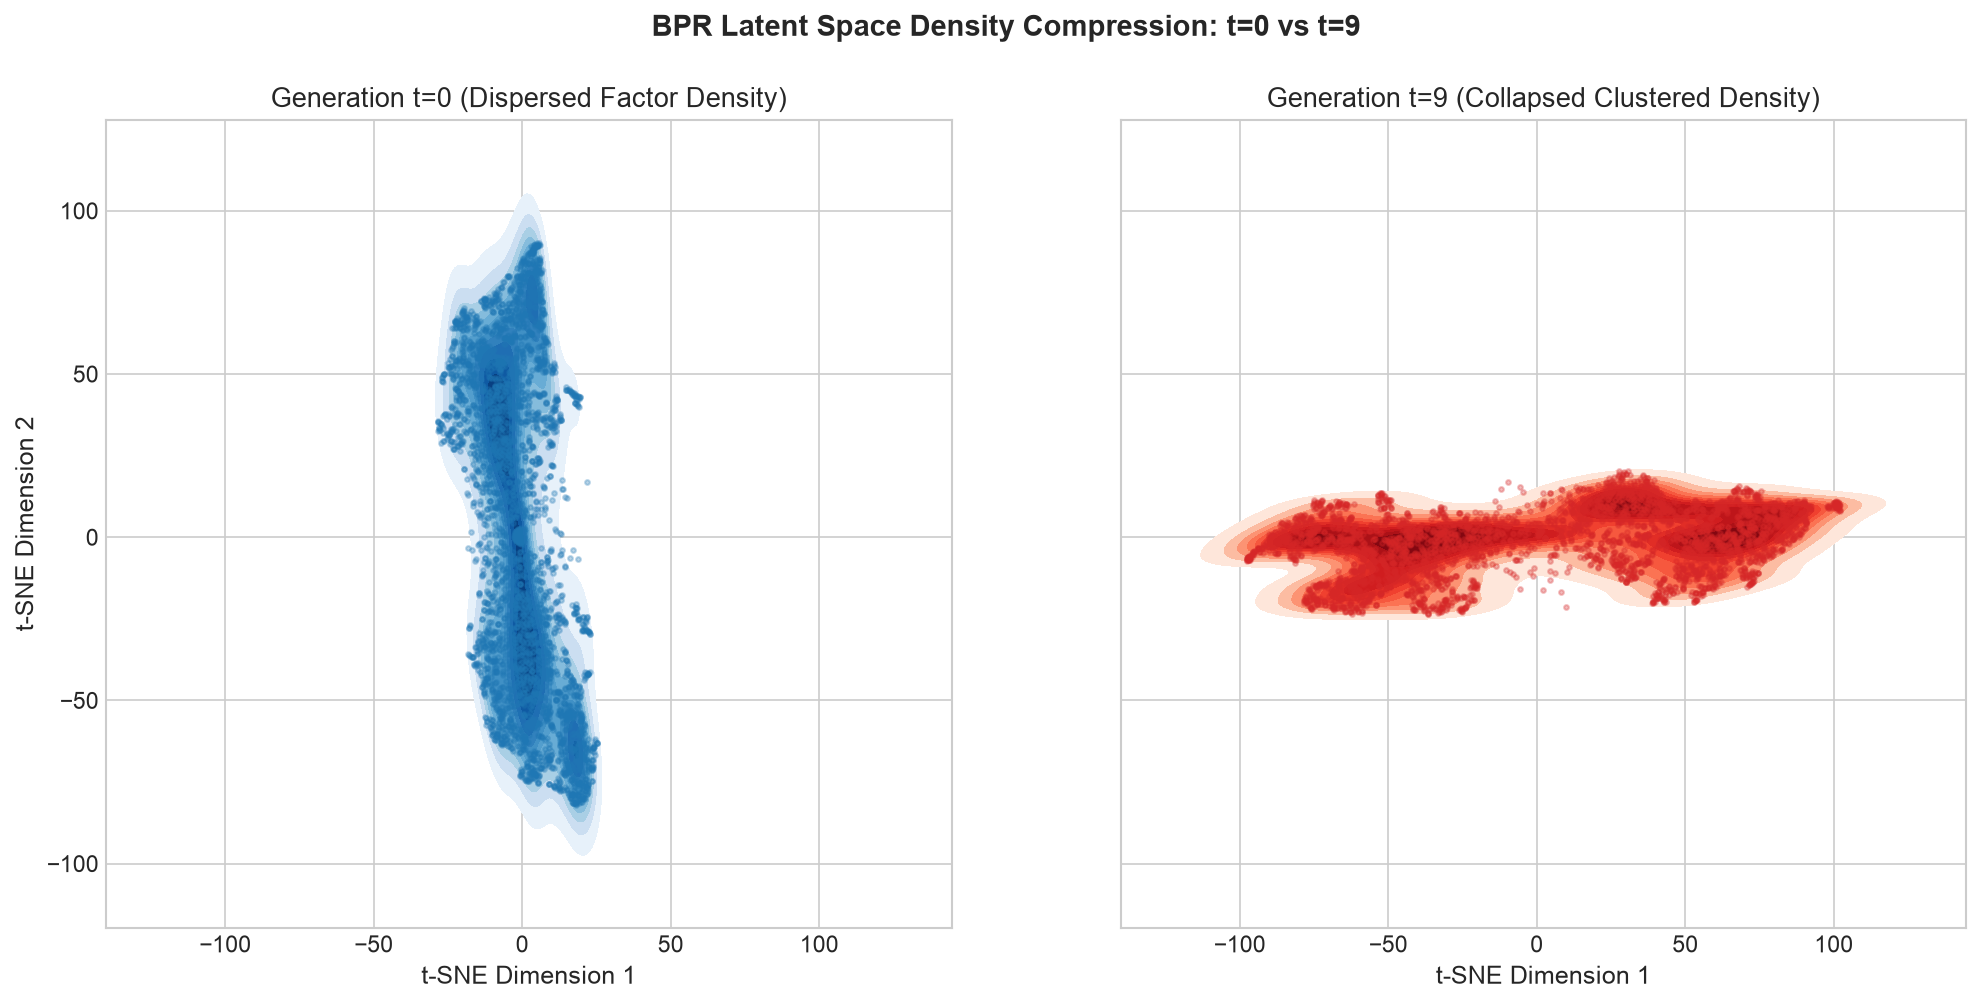

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
fig.suptitle('BPR Latent Space Density Compression: t=0 vs t=9', fontsize=14, fontweight='bold')

sns.kdeplot(x=coords_0[:, 0], y=coords_0[:, 1], ax=axes[0], cmap='Blues', fill=True, levels=12, thresh=0.05)
axes[0].scatter(coords_0[:, 0], coords_0[:, 1], color='#1f77b4', s=5, alpha=0.3)
axes[0].set_title('Generation t=0 (Dispersed Factor Density)')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')

sns.kdeplot(x=coords_final[:, 0], y=coords_final[:, 1], ax=axes[1], cmap='Reds', fill=True, levels=12, thresh=0.05)
axes[1].scatter(coords_final[:, 0], coords_final[:, 1], color='#d62728', s=5, alpha=0.3)
axes[1].set_title('Generation t=9 (Collapsed Clustered Density)')
axes[1].set_xlabel('t-SNE Dimension 1')

plt.show()


## 7. Dynamic 50-Generation Embedding Drift Animation (GIF)

Below is an animated 50-generation trajectory tracking continuous closed-loop feedback across $T=50$ iterations ($t=0 \to 49$).

* **Left Panel**: 2D projection of all 3,533 movies (colored by log-popularity). Red arrows and trails trace the migration of the top-30 most popular blockbusters into dense attractor hubs.
* **Right Panels**: Real-time tracking of **Catalog Exposure Inequality (Gini)** climbing upward and **Latent Manifold Effective Rank** decaying frame-by-frame.


In [ ]:
from IPython.display import Image as IPImage, display

gif_path = '../docs/images/phase_4_tsne_visualization/embedding_drift_trajectory.gif'
display(IPImage(filename=gif_path, width=900))
